In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

datasets = {
    "Test 1": (np.array([0, 15, 30, 45, 60, 75, 90, 98]),np.array([4.9, 3.5, 2.7, 2.0, 1.4, 0.8, 0.2, 0]) * 10),
    "Test 2": (np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165]),np.array([4.9, 3.9, 3.3, 2.7, 2.2, 1.7, 1.4, 1.0, 0.7, 0.4, 0.2, 0]) * 10),
    "Test 3": (np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 194]),np.array([5, 4.4, 3.9, 3.2, 2.9, 2.3, 1.9, 1.5, 1.2, 0.9, 0.6, 0.4, 0.2, 0]) * 10),
    "Test 4": (np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 209]),np.array([5, 4.3, 3.6, 3.1, 2.8, 2.5, 2, 1.6, 1.5, 1.2, 0.8, 0.6, 0.4, 0.2, 0]) * 10),
    "Test 5": (np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 223]),np.array([5.1, 4.4, 3.9, 3.4, 2.9, 2.5, 2.1, 1.8, 1.6, 1.4, 1.1, 0.8, 0.5, 0.4, 0.2, 0]) * 10),
    "Test 6": (np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 223]),np.array([5.1, 4.5, 3.8, 3.4, 2.9, 2.4, 2.1, 1.6, 1.3, 1.1, 0.9, 0.7, 0.4, 0.3, 0.2, 0]) * 10),
    "Test 7": (np.array([0, 15, 30, 45, 60, 75, 90, 105, 120, 135, 150, 165, 180, 195, 210, 225, 231]),np.array([4.8, 3.9, 3.5, 3, 2.6, 2.3, 2, 1.8, 1.5, 1.2, 1, 0.8, 0.6, 0.5, 0.3, 0.1, 0]) * 10)}

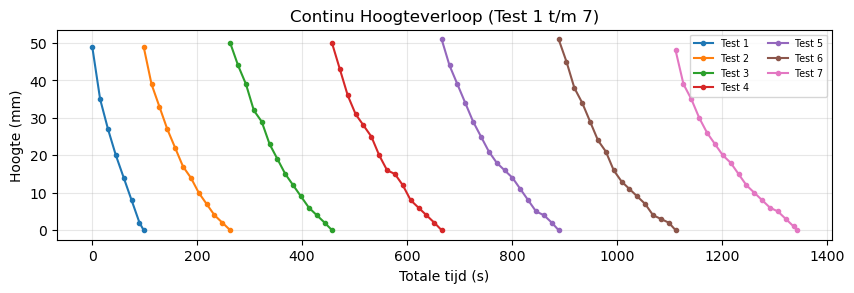

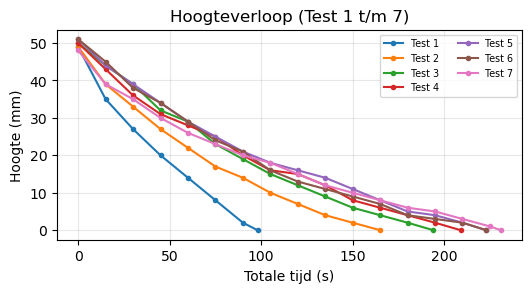

In [2]:
# Grafiek (t, h) doorlopend
offset = 0.0
plt.figure(figsize=(10, 6))

for test_naam, (t, h) in datasets.items():
    t_doorlopend = t + offset

    plt.subplot(2, 1, 1)
    plt.plot(t_doorlopend, h, marker='.', label=test_naam)
    offset += t[-1]

    plt.title("Continu Hoogteverloop (Test 1 t/m 7)")
    plt.xlabel("Totale tijd (s)")
    plt.ylabel("Hoogte (mm)")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize='x-small')

# Grafiek (t, h) overlappend
plt.figure(figsize=(6, 6))

for test_naam, (t, h) in datasets.items():
    plt.subplot(2, 1, 2)
    plt.plot(t, h, marker='.', label=test_naam)

    plt.title("Hoogteverloop (Test 1 t/m 7)")
    plt.xlabel("Totale tijd (s)")
    plt.ylabel("Hoogte (mm)")
    plt.grid(True, alpha=0.3)
    plt.legend(ncol=2, fontsize='x-small')


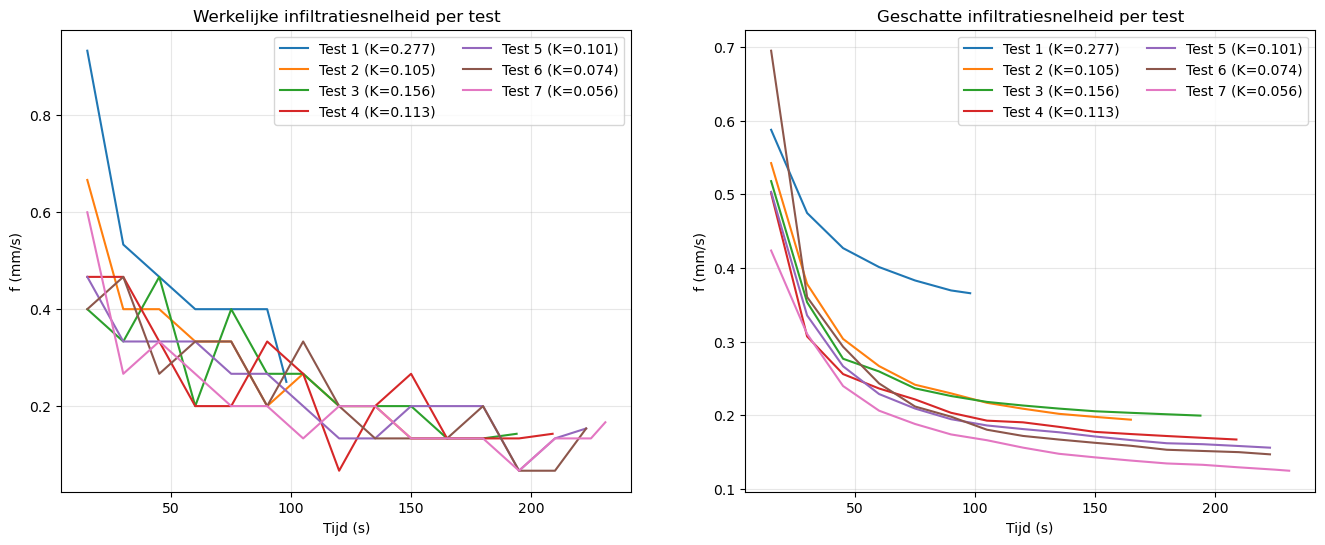

In [3]:
def green_ampt_t_model(F, K, S):
    return (1/K) * (F - S * np.log(1 + F/S))

def green_ampt_f_model(F, K, S):
    return K * (S/F + 1)

def combined_objective(F, K, S):
    t_pred = green_ampt_t_model(F, K, S)
    f_pred = green_ampt_f_model(F, K, S)
    return np.concatenate([t_pred, f_pred])

results = []
plt.figure(figsize=(25, 6))

# Infiltratiesnelheid 
for naam, (t, h) in datasets.items():
    F = h[0] - h
    f_actual = -np.diff(h) / np.diff(t)
    y_combined = np.concatenate([t[1:], f_actual])
    
    params, covariance = curve_fit(lambda F, K, S: combined_objective(F, K, S), F[1:], y_combined, p0=[0.1, 20])
    K_fit, S_fit = params
    stdevs = np.sqrt(np.diag(covariance)) 
        
    f_pred = green_ampt_f_model(F[1:], K_fit, S_fit)

    # Werkelijke infiltratiesnelheid
    plt.subplot(1, 3, 1)
    plt.plot(t[1:], f_actual, label=f"{naam} (K={K_fit:.3f})")
    plt.title("Werkelijke infiltratiesnelheid per test")
    plt.xlabel("Tijd (s)")
    plt.ylabel("f (mm/s)")
    plt.legend(ncol=2)
    plt.grid(True, alpha=0.3)

    # Geschatte infiltratiesnelheid
    plt.subplot(1, 3, 2)
    plt.plot(t[1:], f_pred, label=f"{naam} (K={K_fit:.3f})")
    plt.title("Geschatte infiltratiesnelheid per test")
    plt.xlabel("Tijd (s)")
    plt.ylabel("f (mm/s)")
    plt.legend(ncol=2)
    plt.grid(True, alpha=0.3)
    
    results.append({"Test": naam, "K (mm/s)": K_fit, "std_K": stdevs[0],"S": S_fit,"std_S": stdevs[1]})


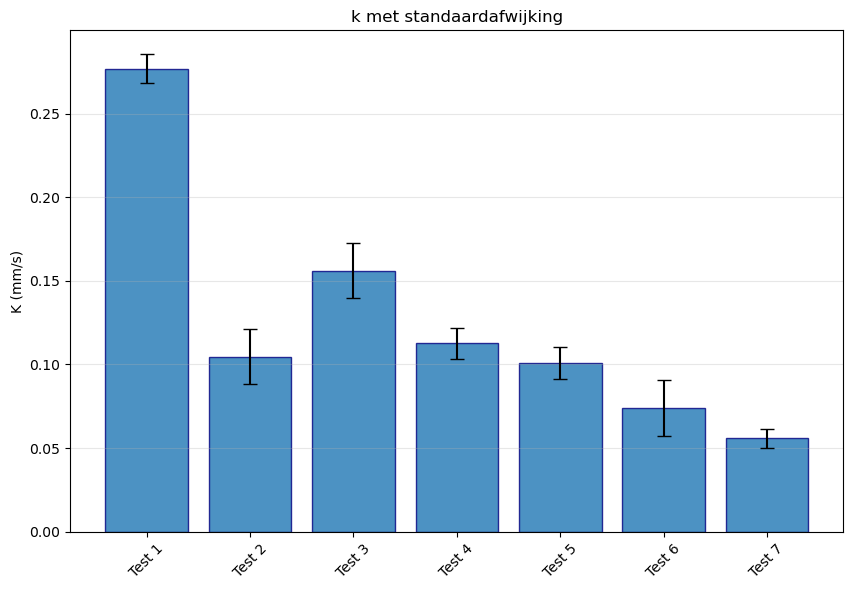

Eindresultaten Geoptimaliseerde Combined Fit
  Test  K (mm/s)    std_K         S     std_S
Test 1  0.276925 0.008698 15.699429  1.172317
Test 2  0.104688 0.016248 41.798438 10.323845
Test 3  0.156116 0.016303 13.900171  3.666085
Test 4  0.112643 0.009362 24.157588  3.920918
Test 5  0.100754 0.009424 27.961367  4.850983
Test 6  0.073890 0.016813 50.419828 17.422617
Test 7  0.055731 0.005779 59.404120  8.745651


In [4]:
# K tabel en grafiek met SD
plt.figure(figsize=(25, 6))

df_results = pd.DataFrame(results)

plt.subplot(1, 3, 3)
plt.bar(df_results["Test"], df_results["K (mm/s)"], yerr=df_results["std_K"], capsize=5, edgecolor='navy', alpha=0.8)
plt.title("k met standaardafwijking")
plt.ylabel("K (mm/s)")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print("Eindresultaten Geoptimaliseerde Combined Fit")
print(df_results[["Test", "K (mm/s)", "std_K", "S", "std_S"]].to_string(index=False))